<div style="background:linear-gradient(135deg,#17211B,#26352A); padding:24px 28px; border-radius:16px; border:1px solid #84A98C; box-shadow:0 0 18px rgba(132,169,140,0.14); margin-top:30px;">

<div style="font-size:13px; color:#F4A261; letter-spacing:2px; margin-bottom:8px; font-weight:bold;">
🧪 HANDS-ON LAB
</div>

<h2 style="color:#F1FAEE; margin:0; line-height:1.4;">
Univariate EDA on an E-Commerce Dataset
</h2>

<div style="height:3px; width:90px; background:#84A98C; margin:14px 0; border-radius:4px;"></div>

<p style="color:#D8E2DC; font-size:15px; line-height:1.8; margin:0;">
In this lab, we will apply <b style="color:#A8DADC;">Univariate Exploratory Data Analysis (EDA)</b>
techniques to our e-commerce product performance dataset.
</p>

<p style="color:#D8E2DC; font-size:15px; line-height:1.8; margin:10px 0 0 0;">
The goal is to understand the dataset's
<b style="color:#F4A261;">distributions</b>, detect potential
<b style="color:#F4A261;">outliers</b>, and discover patterns before applying
Machine Learning models.
</p>

</div>

<h2 style="color:#A8DADC; border-left:5px solid #F4A261; padding:10px 15px; background:#17211B; border-radius:8px;">
🔹 Step 1 — Explore Numeric Variables
</h2>

<div style="background:#26352A; border-left:4px solid #84A98C; padding:16px 18px; margin:15px 0; border-radius:8px;">

<p style="color:#D8E2DC; line-height:1.8; margin:0;">
First, we load the <b style="color:#F4A261;">E-Commerce Product Performance</b>
dataset and identify its numeric variables.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:10px 0 0 0;">
Histograms help us understand how variables such as
<b style="color:#A8DADC;">Product Price</b>,
<b style="color:#A8DADC;">Number of Reviews</b>, and
<b style="color:#A8DADC;">Days to Deliver</b> are distributed.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:10px 0 0 0;">
This gives us an initial view of the data and helps us notice
<b style="color:#F4A261;">skewness, concentration, gaps, and unusual values</b>.
</p>

</div>

In [10]:
import pandas as pd

df = pd.read_csv("ecommerce_product_performance.csv")

print("Dataset Shape:", df.shape)
display(df.head(10))
numeric_columns = df.select_dtypes(include="number").columns

print("\033[94mNumeric Columns:\033[0m")
print(numeric_columns)

Dataset Shape: (2000, 8)


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
0,199.671415,0.177024,4.411071,62.0,1.0,9.0,0.185116,5.0
1,136.173570,0.041467,3.033534,201.0,1.0,3.0,0.384639,10.0
2,214.768854,0.276197,2.866881,479.0,1.0,19.0,0.056410,4.0
3,302.302986,0.094254,4.473473,252.0,1.0,11.0,NaN,7.0
4,126.584663,0.411845,3.553082,671.0,1.0,14.0,0.672163,6.0
5,126.586304,0.515701,1.874022,303.0,NaN,2.0,0.114370,7.0
6,307.921282,0.634228,NaN,350.0,1.0,7.0,0.172875,6.0
7,226.743473,0.271702,3.366010,330.0,1.0,10.0,0.091893,2.0
8,103.052561,0.161156,5.000000,179.0,1.0,10.0,0.533085,7.0
9,204.256004,0.301962,5.000000,350.0,1.0,20.0,0.480863,8.0


Numeric Columns:
Index(['Product_Price', 'Discount_Rate', 'Product_Rating', 'Number_of_Reviews',
       'Stock_Availability', 'Days_to_Deliver', 'Return_Rate', 'Category_ID'],
      dtype='str')


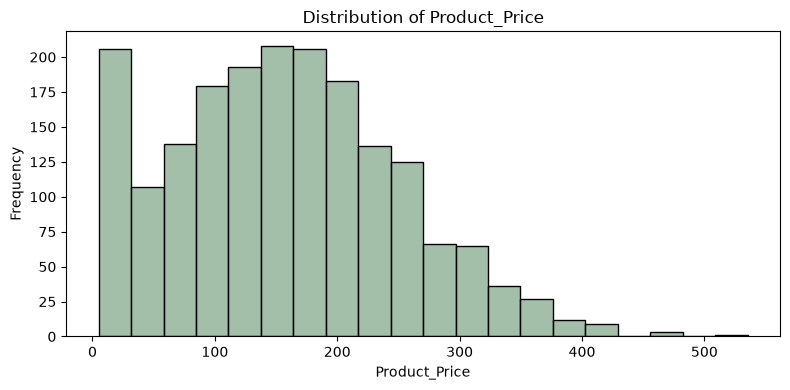

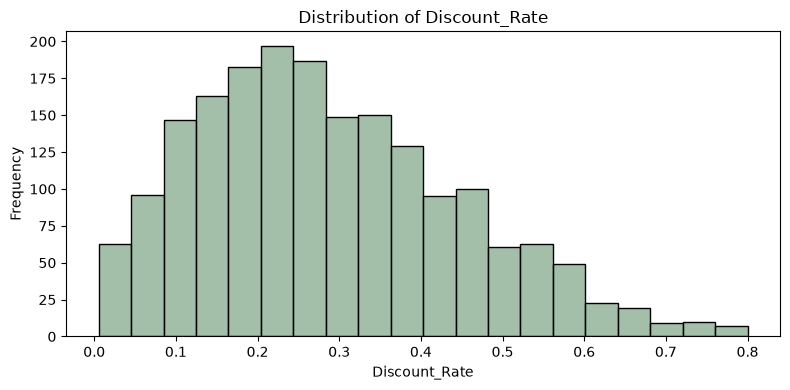

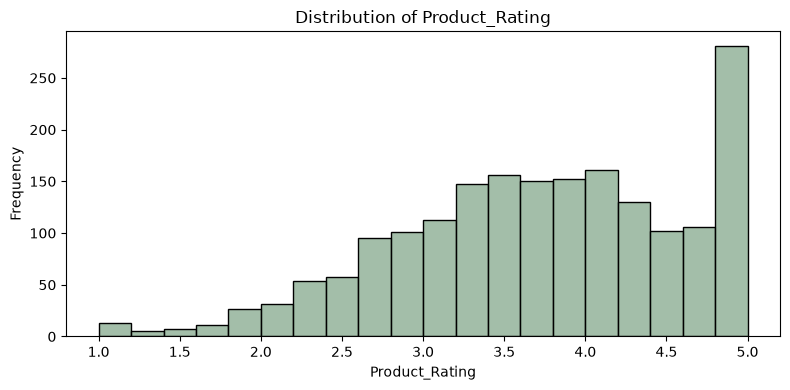

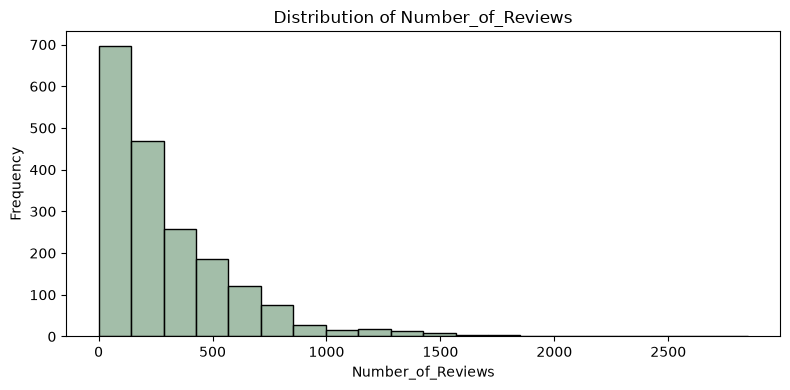

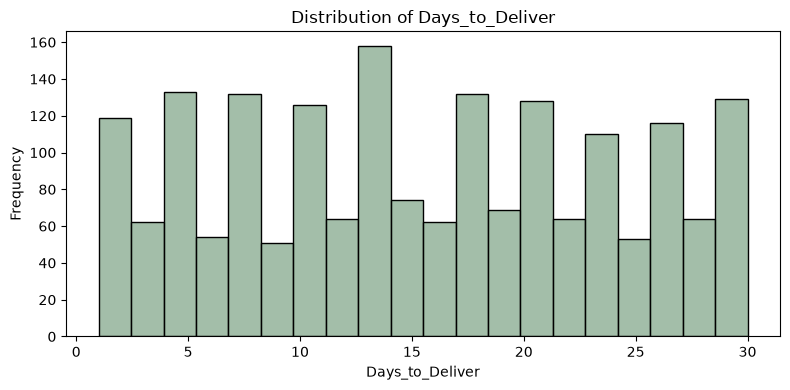

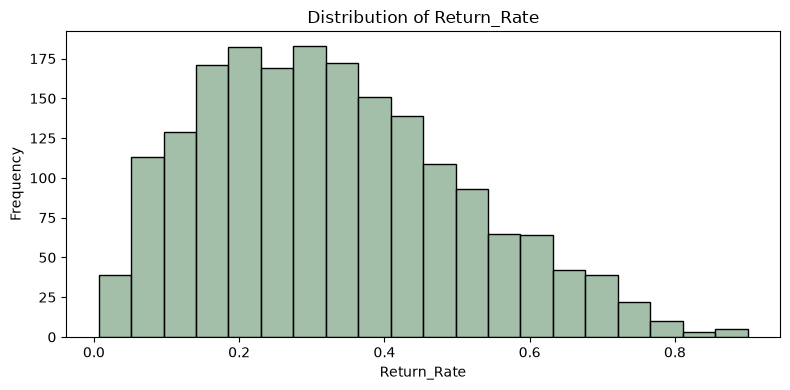

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_columns = [
    "Product_Price",
    "Discount_Rate",
    "Product_Rating",
    "Number_of_Reviews",
    "Days_to_Deliver",
    "Return_Rate"
]

for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        bins=20,
        color="#84A98C"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

<div style="background:#26352A; border-left:5px solid #F4A261; padding:16px 18px; margin:20px 0; border-radius:10px;">

<h3 style="color:#A8DADC; margin:0 0 8px 0;">
📦 Step 2 — Detect Outliers Visually
</h3>

<p style="color:#D8E2DC; line-height:1.8; margin:0;">
Box plots provide a quick visual way to identify
<b style="color:#F4A261;">potential outliers</b> in the numeric variables.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:8px 0 0 0;">
Values outside the whiskers may require further investigation before deciding
whether they represent unusual observations or data issues.
</p>

</div>

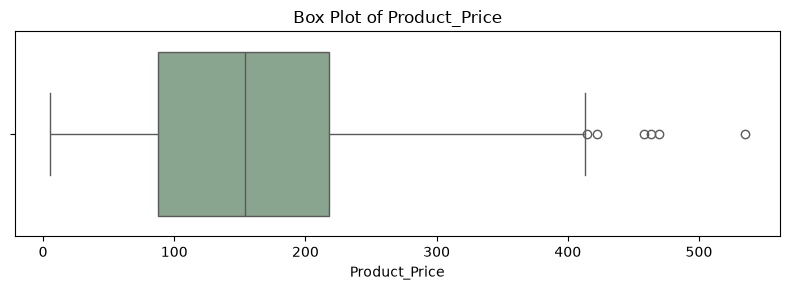

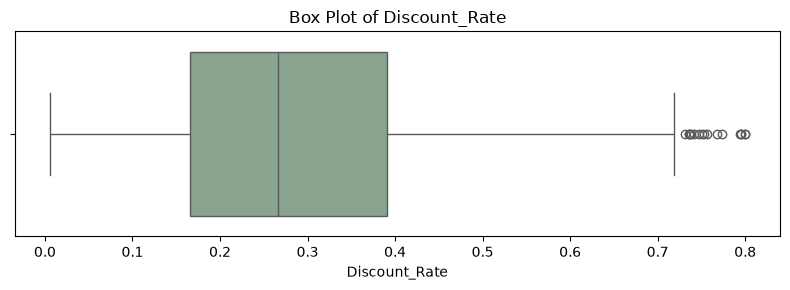

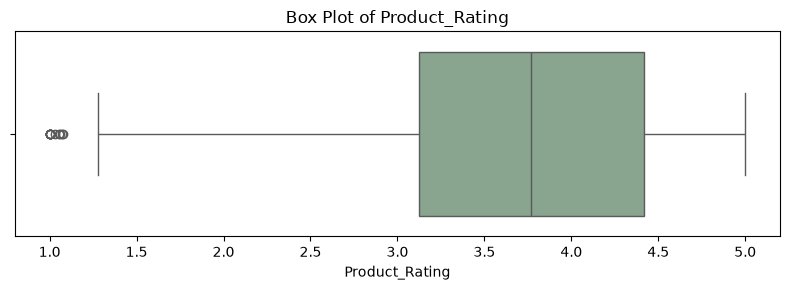

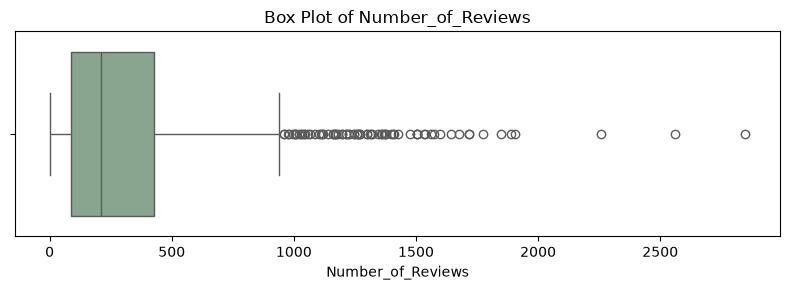

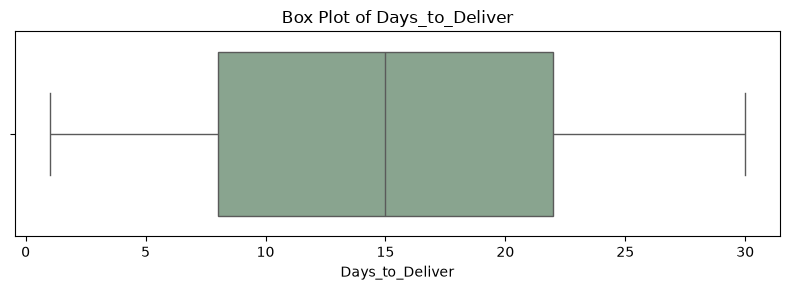

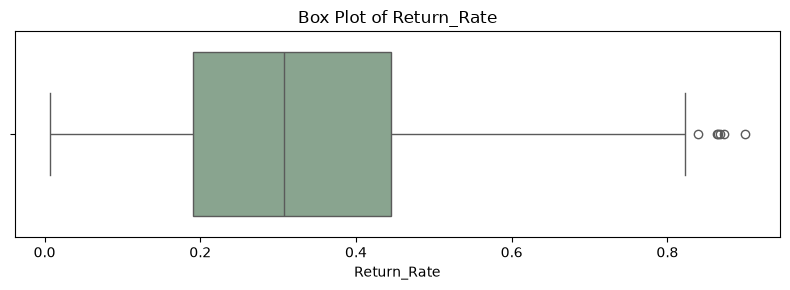

In [12]:
for column in numeric_columns:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column,
        color="#84A98C"
    )

    plt.title(f"Box Plot of {column}")
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

<div style="background:#26352A; border-left:5px solid #F4A261; padding:16px 18px; margin:20px 0; border-radius:10px;">

<h3 style="color:#A8DADC; margin:0 0 8px 0;">
📐 Step 3 — Apply IQR Outlier Detection
</h3>

<p style="color:#D8E2DC; line-height:1.8; margin:0;">
We apply the <b style="color:#F4A261;">IQR method</b> to detect potential
outliers in the <b style="color:#A8DADC;">Number_of_Reviews</b> variable.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:8px 0 0 0;">
After detecting potential outliers, we investigate whether they represent
<b style="color:#A8DADC;">valid product observations</b> or possible data issues.
</p>

</div>

In [13]:
column = "Number_of_Reviews"

Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[column] < lower_bound) |
    (df[column] > upper_bound)
]

print("\033[91mNumber of detected outliers:\033[0m", len(outliers))

outliers.head()

Number of detected outliers: 75


,Product_Price,Discount_Rate,Product_Rating,Number_of_Reviews,Stock_Availability,Days_to_Deliver,Return_Rate,Category_ID
48,NaN,NaN,5.00000,1300.0,1.0,22.0,0.321321,9.0
59,247.554513,0.176769,NaN,977.0,1.0,26.0,0.088149,9.0
61,131.434102,0.397173,2.18525,1316.0,1.0,22.0,0.225413,1.0
68,186.163603,0.243699,5.00000,1298.0,1.0,11.0,0.159424,5.0
80,128.032811,0.400997,5.00000,1226.0,0.0,21.0,0.020199,5.0


<div style="background:#26352A; border-left:5px solid #84A98C; padding:16px 18px; margin:20px 0; border-radius:10px;">

<h3 style="color:#A8DADC; margin:0 0 8px 0;">
📊 Step 4 — Analyze Categorical Variables
</h3>

<p style="color:#D8E2DC; line-height:1.8; margin:0;">
Count plots show how frequently each category appears.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:8px 0 0 0;">
They help us understand categorical distributions and identify
<b style="color:#F4A261;">imbalanced or dominant categories</b>.
</p>

<p style="color:#D8E2DC; line-height:1.8; margin:8px 0 0 0;">
In this dataset, <b style="color:#A8DADC;">Category_ID</b> and
<b style="color:#A8DADC;">Stock_Availability</b> are stored as numbers,
but they represent categorical information.
</p>

</div>

In [14]:
categorical_columns = [
    "Category_ID",
    "Stock_Availability"
]

print("\033[94mCategorical Columns:\033[0m")

for col in categorical_columns:
    print("\033[92m✓\033[0m", col)

Categorical Columns:
✓ Category_ID
✓ Stock_Availability


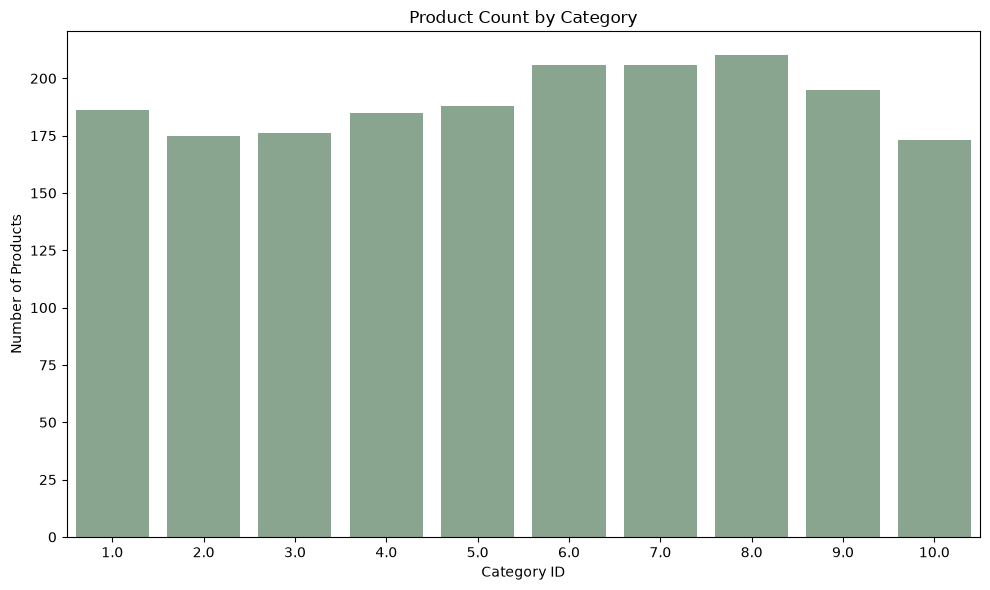

In [15]:
category_counts = df["Category_ID"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Category_ID",
    order=category_counts.index,
    color="#84A98C"
)

plt.title("Product Count by Category")
plt.xlabel("Category ID")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

<div style="background:linear-gradient(135deg,#17211B,#26352A); padding:24px 28px; border-radius:16px; border:1px solid #84A98C; margin-top:25px;">

<h2 style="color:#A8DADC; margin:0 0 15px 0;">
🔹 Step 5 — Data Insights
</h2>

<div style="height:3px; width:90px; background:#F4A261; margin-bottom:16px; border-radius:4px;"></div>

<p style="color:#D8E2DC; line-height:1.8; margin:0 0 10px 0;">
After performing EDA, we can summarize the main characteristics of the
<b style="color:#F4A261;">E-Commerce Product Performance</b> dataset:
</p>

<ul style="color:#D8E2DC; line-height:2; margin:0;">
<li>📊 The distributions of numeric variables such as product price, ratings, reviews, and delivery time.</li>
<li>⚠️ The presence of potential outliers, especially in variables with highly skewed distributions.</li>
<li>🏷️ The frequency of products across different <b style="color:#A8DADC;">categories</b>.</li>
<li>🔎 Patterns, skewness, concentration, and unusual observations that may require further investigation.</li>
</ul>

<p style="color:#D8E2DC; line-height:1.8; margin:15px 0 0 0;">
EDA gives us a clearer understanding of the data and helps us make better
decisions about <b style="color:#A8DADC;">preprocessing, feature selection,
and Machine Learning models</b> before moving to the modeling stage.
</p>

</div>